In [2]:
import sys
sys.path.append("..")

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipeline.data_processor import DataProcessor

sns.set_style("whitegrid")
%matplotlib inline


In [3]:
processor = DataProcessor()
jobs, x_train, y_train, x_test = processor.load_data()

print(f"Jobs: {len(jobs)}")
print(f"Train sessions: {len(x_train)}")
print(f"Test sessions: {len(x_test)}")

display(x_train.head())
display(y_train.head())


Jobs: 21917
Train sessions: 15882
Test sessions: 1819


,session_id,job_ids,actions
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view..."
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']"
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a..."
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ..."
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ..."


,session_id,job_id,action
0,0,84,view
1,1,241,view
2,2,303,apply
3,3,171,apply
4,4,286,apply


## 1st Pipeline

Use raw navigation data from each session → transform it into numerical features per session  
(each session is represented by one row).

With this, we will answer questions about **how the user navigates**  
(nothing about *what* the job is, for now).

### Possible questions
- How many job offers did the user browse during the session?
- How many applies?
- What was the last action?
- Is the session in an exploration phase?
- Was there repetition?
- When did the first apply occur?

### What we do NOT want to know at this stage
- How many skills the job has
- Job text
- Semantic similarity
- Job category


1st goal: Transform job_ids and actions  string → list -> with this will be possible to count values

In [4]:
import ast

def parse_list_column(value):
    """
    Recebe uma string do tipo "[1, 2, 3]" ou "['view', 'apply']"
    e devolve uma lista Python real.
    """
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return ast.literal_eval(value)
    return []


x_train["jobs_list"] = x_train["job_ids"].apply(parse_list_column)
x_train["actions_list"] = x_train["actions"].apply(parse_list_column)

x_test["jobs_list"] = x_test["job_ids"].apply(parse_list_column)
x_test["actions_list"] = x_test["actions"].apply(parse_list_column)

display(x_train[["session_id", "jobs_list", "actions_list"]].head())



,session_id,jobs_list,actions_list
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]"
1,1,"[84, 257, 252, 250]","[view, view, view, view]"
2,2,"[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]"
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app..."
4,4,"[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]"


In [5]:
# Creating a new feature -> sequence length
x_train["seq_length"] = x_train["jobs_list"].apply(len)

#feature needs to be added to test set as well
x_test["seq_length"] = x_test["jobs_list"].apply(len)


x_train[["session_id", "jobs_list", "seq_length"]].head()

,session_id,jobs_list,seq_length
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]",8
1,1,"[84, 257, 252, 250]",4
2,2,"[241, 237, 221, 309, 310, 306, 301]",7
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]",8
4,4,"[171, 291, 289, 166, 288, 155]",6


In [6]:
x_train["seq_length"].describe()

count    15882.000000
mean         7.539793
std          3.577731
min          3.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         15.000000
Name: seq_length, dtype: float64

- From the 15882 training sessions, all of them have a defined `seq_length`  

- There is clear evidence of active navigation, as a user opens on average 7 to 8 job postings per session.

- User behavior varies significantly once some sessions are short, while others are considerably longer,  indicating different navigation patterns.

In [7]:
# creating a new feature -> number of apply actions
def count_apply(actions):
    return actions.count("apply")

x_train["num_apply"] = x_train["actions_list"].apply(count_apply)

# feature needs to be added to test set as well
x_test["num_apply"]  = x_test["actions_list"].apply(count_apply)
x_train[["session_id", "jobs_list", "actions_list", "seq_length", "num_apply"]].head()

,session_id,jobs_list,actions_list,seq_length,num_apply
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",8,0
1,1,"[84, 257, 252, 250]","[view, view, view, view]",4,0
2,2,"[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",7,5
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",8,8
4,4,"[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",6,6


In [8]:
x_train["num_apply"].describe()


count    15882.000000
mean         2.747261
std          3.476889
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         15.000000
Name: num_apply, dtype: float64

## Apply Behavior Insights

- Min = 0 --> indicates that there are sessions in which the user did not apply to any job.  The 25th percentile = 0 shows that one quarter of the sessions have no applications, meaning these are purely exploration sessions.

- On average, there are ~2.7 applies per session. However, some sessions contain a high number of applies, which pulls the mean upward (std confirms the existence of this variability).

- There are sessions in which the user applied up to 15 times --> max seq_length = 15 (we saw this before) -> this suggests that in some sessions the user applied to every job they viewed — potentially indicating mass application behavior, for exemple.


The `num_apply` feature seems to be informative for predicting the next action. Once the user has already applied multiple times within a session, the likelihood of continuing to apply increases...

In [9]:
# just to check 
(x_train["num_apply"] <= x_train["seq_length"]).all()


np.True_

In [10]:
x_train["num_view"] = x_train["seq_length"] - x_train["num_apply"]
x_test["num_view"] = x_test["seq_length"] - x_test["num_apply"]

x_train[["session_id", "seq_length", "num_view", "num_apply"]].head()


,session_id,seq_length,num_view,num_apply
0,0,8,8,0
1,1,4,4,0
2,2,7,2,5
3,3,8,0,8
4,4,6,0,6


In [11]:
# just to check
(x_train["num_view"] + x_train["num_apply"] == x_train["seq_length"]).all()


np.True_

In [12]:
#descriptive statistics
x_train[["seq_length", "num_view", "num_apply"]].describe()

,seq_length,num_view,num_apply
count,15882.000000,15882.000000,15882.000000
mean,7.539793,4.792532,2.747261
std,3.577731,3.841545,3.476889
min,3.000000,0.000000,0.000000
25%,4.000000,2.000000,0.000000
50%,7.000000,4.000000,1.000000
75%,10.000000,7.000000,4.000000
max,15.000000,15.000000,15.000000


In [13]:
only_view = (x_train["num_apply"] == 0).mean()
only_apply = (x_train["num_view"] == 0).mean()

print(f"% section view: {only_view:.2%}")
print(f"% section apply: {only_apply:.2%}")

% section view: 42.18%
% section apply: 15.97%


These results confirm  --> users typically explore multiple job offers before applying to a smaller subset.

##  `apply_ratio` can be representative, as it allows comparison between short and long sessions

In [14]:
x_train["apply_ratio"] = x_train["num_apply"] / x_train["seq_length"]
x_test["apply_ratio"]  = x_test["num_apply"] / x_test["seq_length"]

x_train[["session_id",  "seq_length","num_view", "num_apply","actions_list" ,"apply_ratio"]].head()


,session_id,seq_length,num_view,num_apply,actions_list,apply_ratio
0,0,8,8,0,"[view, view, view, view, view, view, view, view]",0.000000
1,1,4,4,0,"[view, view, view, view]",0.000000
2,2,7,2,5,"[view, view, apply, apply, apply, apply, apply]",0.714286
3,3,8,0,8,"[apply, apply, apply, apply, apply, apply, app...",1.000000
4,4,6,0,6,"[apply, apply, apply, apply, apply, apply]",1.000000


In [15]:
x_train["apply_ratio"].describe()


count    15882.000000
mean         0.357299
std          0.386012
min          0.000000
25%          0.000000
50%          0.230769
75%          0.692308
max          1.000000
Name: apply_ratio, dtype: float64

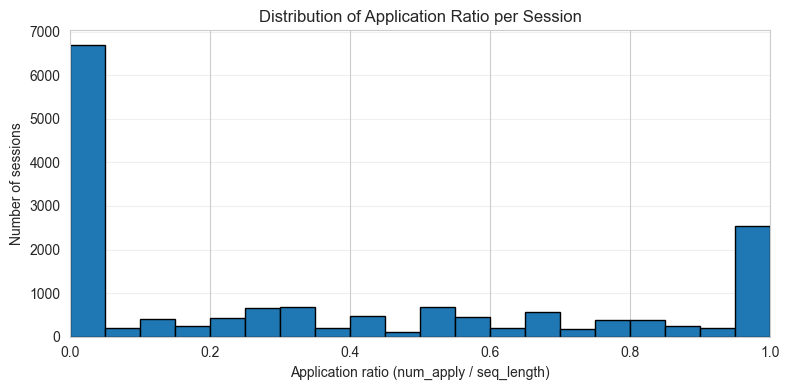

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(x_train["apply_ratio"], bins=20, edgecolor="black")
plt.title("Distribution of Application Ratio per Session")
plt.xlabel("Application ratio (num_apply / seq_length)")
plt.ylabel("Number of sessions")
plt.grid(axis="y", alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Session Typology Based on apply_ratio
- Exploratory sessions (apply_ratio -> ~0)  
- Decisive sessions (high apply_ratio -> ~1)
- A large number of users fall “in between” these two extremes -> mixed behavior exploration x application.

## The goal is to identify the current state of a session.
To do this, we look at what happened last and what happened immediately before that -> We also check whether there was a change of state in these most recent events.

In [17]:
# last and previous action features
# last action
def last_item(lst):
    return lst[-1]

# previous action
def prev_item(lst):
    # penúltimo elemento
    return lst[-2]

# if last two actions are different
def changed_last_two(actions):
    # 1: last action is different from previous
    # 0: last action is the same as previous
    return int(actions[-1] != actions[-2])



In [18]:
# last job and action -> we always have at least one action in the session
x_train["last_job_id"] = x_train["jobs_list"].apply(last_item)
x_test["last_job_id"]  = x_test["jobs_list"].apply(last_item)

x_train["last_action"] = x_train["actions_list"].apply(last_item)
x_test["last_action"]  = x_test["actions_list"].apply(last_item)

# previous job and action 
x_train["prev_job_id"] = x_train["jobs_list"].apply(prev_item)
x_test["prev_job_id"]  = x_test["jobs_list"].apply(prev_item)

x_train["prev_action"] = x_train["actions_list"].apply(prev_item)
x_test["prev_action"]  = x_test["actions_list"].apply(prev_item)

# if last two actions are different
x_train["action_changed"] = x_train["actions_list"].apply(changed_last_two)
x_test["action_changed"]  = x_test["actions_list"].apply(changed_last_two)

x_train[["session_id","jobs_list", "actions_list","last_job_id","last_action","prev_job_id","prev_action","action_changed"]].head()


,session_id,jobs_list,actions_list,last_job_id,last_action,prev_job_id,prev_action,action_changed
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",261,view,264,view,0
1,1,"[84, 257, 252, 250]","[view, view, view, view]",250,view,252,view,0
2,2,"[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",301,apply,306,apply,0
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",293,apply,292,apply,0
4,4,"[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",155,apply,288,apply,0


In [19]:
x_train["last_action"].value_counts(normalize=True) * 100


last_action
view     60.571716
apply    39.428284
Name: proportion, dtype: float64

In 61% of the sessions the last action was just view a job posting, but in 39% of the sessions, user ends the session by applying to a job.

Then:
- The user does not always apply at the end of a session.  
- The behavior is mixed (exploratory and decisive application endings)

In [20]:
x_train["action_changed"].value_counts(normalize=True) * 100


action_changed
0    85.291525
1    14.708475
Name: proportion, dtype: float64

prev_action != last_action !!!

Users tend to maintain the same type of action at the end of the session. (Only 15% of sessions present an action change in the final stage)

In [21]:
session_features_train = x_train[[
    "session_id",
    "seq_length",
    "num_view",
    "num_apply",
    "apply_ratio",
    "last_job_id",
    "last_action",
    "prev_job_id",
    "prev_action",
    "action_changed"
]].copy()

session_features_test = x_test[[
    "session_id",
    "seq_length",
    "num_view",
    "num_apply",
    "apply_ratio",
    "last_job_id",
    "last_action",
    "prev_job_id",
    "prev_action",
    "action_changed"
]].copy()

session_features_train.head()



,session_id,seq_length,num_view,num_apply,apply_ratio,last_job_id,last_action,prev_job_id,prev_action,action_changed
0,0,8,8,0,0.000000,261,view,264,view,0
1,1,4,4,0,0.000000,250,view,252,view,0
2,2,7,2,5,0.714286,301,apply,306,apply,0
3,3,8,0,8,1.000000,293,apply,292,apply,0
4,4,6,0,6,1.000000,155,apply,288,apply,0


In [25]:
def to_binary_actions(actions, mapping={"view": False, "apply": True}):
    return [mapping[a] for a in actions]

x_train["actions_bin"] = x_train["actions_list"].apply(to_binary_actions)
x_test["actions_bin"]  = x_test["actions_list"].apply(to_binary_actions)

x_train[["session_id", "actions_list", "actions_bin"]].head()


,session_id,actions_list,actions_bin
0,0,"[view, view, view, view, view, view, view, view]","[False, False, False, False, False, False, Fal..."
1,1,"[view, view, view, view]","[False, False, False, False]"
2,2,"[view, view, apply, apply, apply, apply, apply]","[False, False, True, True, True, True, True]"
3,3,"[apply, apply, apply, apply, apply, apply, app...","[True, True, True, True, True, True, True, True]"
4,4,"[apply, apply, apply, apply, apply, apply]","[True, True, True, True, True, True]"


In [30]:
def max_consecutive(actions, target):
    """
    Retorna o maior número de ocorrências consecutivas de `target`
    dentro da lista `actions`.
    """
    best = 0
    current = 0
    
    for a in actions:
        if a == target:
            current += 1
            if current > best:
                best = current
        else:
            current = 0
    
    return best


In [31]:
def tail_consecutive(actions, target):
    """
    Retorna quantos `target` consecutivos existem no FINAL da lista.
    """
    count = 0
    for a in reversed(actions):
        if a == target:
            count += 1
        else:
            break
    return count


In [32]:
def switch_count(actions):
    """
    Conta quantas vezes a ação muda entre posições consecutivas.
    Ex: view, view, apply, apply, view -> mudanças = 2 (view->apply, apply->view)
    """
    if len(actions) < 2:
        return 0
    
    changes = 0
    prev = actions[0]
    for a in actions[1:]:
        if a != prev:
            changes += 1
        prev = a
    return changes


In [41]:
def compute_max_view_run(actions):
    return max_consecutive(actions, "view")

def compute_max_apply_run(actions):
    return max_consecutive(actions, "apply")

def compute_last_view_run(actions):
    return tail_consecutive(actions, "view")

def compute_last_apply_run(actions):
    return tail_consecutive(actions, "apply")

x_train["max_view_run"] = x_train["actions_list"].apply(compute_max_view_run)
x_train["max_apply_run"] = x_train["actions_list"].apply(compute_max_apply_run)
x_train["last_view_run"] = x_train["actions_list"].apply(compute_last_view_run)
x_train["last_apply_run"] = x_train["actions_list"].apply(compute_last_apply_run)
x_train["switch_count"] = x_train["actions_list"].apply(switch_count)

x_test["max_view_run"] = x_test["actions_list"].apply(compute_max_view_run)
x_test["max_apply_run"] = x_test["actions_list"].apply(compute_max_apply_run)
x_test["last_view_run"] = x_test["actions_list"].apply(compute_last_view_run)
x_test["last_apply_run"] = x_test["actions_list"].apply(compute_last_apply_run)
x_test["switch_count"] = x_test["actions_list"].apply(switch_count)

x_train[["session_id","seq_length","actions_list","max_view_run","max_apply_run","last_view_run","last_apply_run","switch_count"]].head(20)



,session_id,seq_length,actions_list,max_view_run,max_apply_run,last_view_run,last_apply_run,switch_count
0,0,8,"[view, view, view, view, view, view, view, view]",8,0,8,0,0
1,1,4,"[view, view, view, view]",4,0,4,0,0
2,2,7,"[view, view, apply, apply, apply, apply, apply]",2,5,0,5,1
3,3,8,"[apply, apply, apply, apply, apply, apply, app...",0,8,0,8,0
4,4,6,"[apply, apply, apply, apply, apply, apply]",0,6,0,6,0
5,5,4,"[apply, apply, apply, apply]",0,4,0,4,0
6,6,4,"[apply, apply, apply, apply]",0,4,0,4,0
7,7,3,"[apply, apply, apply]",0,3,0,3,0
8,8,6,"[apply, apply, apply, apply, apply, apply]",0,6,0,6,0
9,9,9,"[apply, apply, apply, apply, apply, apply, app...",0,9,0,9,0


In [ ]:
x_train[["max_view_run","max_apply_run","last_view_run","last_apply_run","switch_count"]].describe()

,max_view_run,max_apply_run,last_view_run,last_apply_run,switch_count
count,15882.000000,15882.000000,15882.000000,15882.000000,15882.000000
mean,4.504030,2.538912,3.510767,1.904798,0.770117
std,3.805866,3.345353,4.070042,3.259876,1.237791
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,2.000000,0.000000,0.000000
75%,7.000000,4.000000,6.000000,3.000000,1.000000
max,15.000000,15.000000,15.000000,15.000000,10.000000


In [36]:
def assign_state_from_runs(apply_ratio, max_view_run, max_apply_run):
    if apply_ratio <= 0.2 or max_view_run >= 4:
        return "exploratory"
    if apply_ratio >= 0.8 or max_apply_run >= 3:
        return "decisive"
    return "mixed"


In [38]:
states = []
for _, row in x_train.iterrows():
    st = assign_state_from_runs(row["apply_ratio"], row["max_view_run"], row["max_apply_run"])
    states.append(st)
x_train["session_state"] = states

states_test = []
for _, row in x_test.iterrows():
    st = assign_state_from_runs(row["apply_ratio"], row["max_view_run"], row["max_apply_run"])
    states_test.append(st)
x_test["session_state"] = states_test
x_train[["session_id","apply_ratio","max_view_run","max_apply_run","session_state"]].head()


,session_id,apply_ratio,max_view_run,max_apply_run,session_state
0,0,0.000000,8,0,exploratory
1,1,0.000000,4,0,exploratory
2,2,0.714286,2,5,decisive
3,3,1.000000,0,8,decisive
4,4,1.000000,0,6,decisive


In [39]:
def add_one_hot_state(df):
    df["is_exploratory"] = (df["session_state"] == "exploratory").astype("int8")
    df["is_mixed"]       = (df["session_state"] == "mixed").astype("int8")
    df["is_decisive"]    = (df["session_state"] == "decisive").astype("int8")
    return df

x_train = add_one_hot_state(x_train)
x_test  = add_one_hot_state(x_test)

x_train[["session_id","apply_ratio","max_view_run","max_apply_run","session_state","is_exploratory","is_mixed","is_decisive"]].head()


,session_id,apply_ratio,max_view_run,max_apply_run,session_state,is_exploratory,is_mixed,is_decisive
0,0,0.000000,8,0,exploratory,1,0,0
1,1,0.000000,4,0,exploratory,1,0,0
2,2,0.714286,2,5,decisive,0,0,1
3,3,1.000000,0,8,decisive,0,0,1
4,4,1.000000,0,6,decisive,0,0,1


In [42]:
x_train["session_state"].value_counts(normalize=True) * 100


session_state
exploratory    59.381690
decisive       29.448432
mixed          11.169878
Name: proportion, dtype: float64